# Final model · Stage 3 — decision layer

**Starting point:** M3-B-mono-nozip + Platt calibration (Stage 2). The model gives a calibrated probability of default (PD).
This stage turns the PD into what a lender acts on:

1. a **loss model** (how much of a loan is lost when it defaults), learned from defaulted **training** loans;
2. **risk bands** R1–R7;
3. **approve / review / decline** thresholds chosen from explicit business targets;
4. **expected loss** in dollars per applicant, back-tested against real losses.

Validation split only; **test sealed**. All rules were fixed in `IMPLEMENTATION_PLAN.md` before looking at the results.

## 1. Setup

In [1]:
import json, sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev
from src.modeling import decision as dl
from src.modeling import reason_codes as rc

STAGE2 = ROOT / "models" / "final" / "02_reason_codes_fairness" / "results"
RESULTS = ROOT / "models" / "final" / "03_decision_layer" / "results"
SEED = 42
choice2 = json.loads((STAGE2 / "final_model_choice.json").read_text(encoding="utf-8"))
calibrator = json.loads((STAGE2 / "calibrator.json").read_text(encoding="utf-8"))
features = choice2["features"]
booster = lgb.Booster(model_file=str(ROOT / choice2["model_file"]))
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| lightgbm", lgb.__version__)
print(f"Final model: {choice2['chosen_model']} ({booster.num_feature()} features, {booster.num_trees()} trees) | "
      f"calibrator: Platt a={calibrator['a']:.4f}, b={calibrator['b']:.4f}")

Python 3.13.9 | scikit-learn 1.7.2 | lightgbm 4.7.0
Final model: M3-B-mono-nozip (146 features, 1931 trees) | calibrator: Platt a=1.0386, b=0.1685


## 2. Data
Validation features (only the model's 146 columns) and the loss table: repayments and recoveries for train + validation loans, taken from the raw CSV by `extract_loss_table.py`. Those columns are outcomes known only *after* a loan ends, so they were never model features; here they are used only to measure losses.

In [2]:
X_val, y_val_frame = ev.load_split("validation", feature_columns=features)
y_val = y_val_frame["target"].astype(int).to_numpy()
loss_table = pd.read_parquet(RESULTS / "loss_table.parquet")
labels = pd.concat([ev.load_split(s, feature_columns=[])[1].assign(split=s) for s in ("train", "validation")])
loss_table = loss_table.merge(labels[["id", "target"]], on="id", how="left", validate="one_to_one")
assert loss_table["target"].notna().all()
val = y_val_frame[["id"]].merge(loss_table, on="id", how="left", validate="one_to_one")
assert (val["target"].to_numpy() == y_val).all(), "loss table is not aligned with the validation split"
print(f"validation: {X_val.shape}, default rate {y_val.mean():.2%}")
print(loss_table.groupby("split").agg(loans=("id", "size"), default_rate=("target", "mean")).round(4))

validation: (162745, 146), default rate 20.35%
             loans  default_rate
split                           
train       388124        0.1724
validation  162745        0.2035


## 3. Final-model PDs
- `pd_cal`: calibrator fitted on all of validation (this is what the engine will output).
- `pd_oof`: 5-fold out-of-fold Platt calibration (same procedure as Stage 2). Thresholds are chosen on `pd_oof` so they are not tuned on in-sample probabilities.

In [3]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

pd_raw = booster.predict(X_val)
pd_cal = dl.calibrate(pd_raw, calibrator)
pd_oof = np.zeros_like(pd_raw)
for fit_idx, out_idx in StratifiedKFold(5, shuffle=True, random_state=SEED).split(pd_raw, y_val):
    lr = LogisticRegression(C=1e6, max_iter=1000).fit(logit(pd_raw[fit_idx]).reshape(-1, 1), y_val[fit_idx])
    pd_oof[out_idx] = lr.predict_proba(logit(pd_raw[out_idx]).reshape(-1, 1))[:, 1]
print(f"ROC-AUC {roc_auc_score(y_val, pd_cal):.4f} (Stage 2 out-of-fold: {choice2['validation_oof']['roc_auc']:.4f})")
print(f"mean PD: full calibrator {pd_cal.mean():.2%} | out-of-fold {pd_oof.mean():.2%} | actual {y_val.mean():.2%}")
print(f"largest |pd_cal - pd_oof|: {np.abs(pd_cal - pd_oof).max():.4f}")

ROC-AUC 0.7351 (Stage 2 out-of-fold: 0.7351)
mean PD: full calibrator 20.35% | out-of-fold 20.35% | actual 20.35%
largest |pd_cal - pd_oof|: 0.0017


## 4. Loss model (defaulted TRAINING loans only)
- **EAD** (exposure at default) = funded amount − principal repaid before default. *EAD share* = total EAD ÷ total funded.
- **LGD** (loss given default) = 1 − net recoveries ÷ EAD, where net recoveries = recoveries − collection-agency fees.
- Both are pooled per term, because 60-month loans have more principal left when they default.

In [4]:
def add_loss_columns(frame):
    frame = frame.copy()
    frame["ead"] = (frame["funded_amnt"] - frame["total_rec_prncp"]).clip(lower=0)
    frame["net_recovery"] = (frame["recoveries"] - frame["collection_recovery_fee"]).clip(lower=0)
    frame["realised_loss"] = np.where(frame["target"] == 1, (frame["ead"] - frame["net_recovery"]).clip(lower=0), 0.0)
    return frame

loss_table = add_loss_columns(loss_table)
val = add_loss_columns(val)
train_defaults = loss_table[(loss_table["split"] == "train") & (loss_table["target"] == 1)]
rows = []
for term, g in [("36", train_defaults[train_defaults["term_months"] == 36]),
                ("60", train_defaults[train_defaults["term_months"] == 60]), ("all", train_defaults)]:
    rows.append({"term": term, "defaulted_loans": len(g), "funded_$m": g["funded_amnt"].sum() / 1e6,
                 "ead_$m": g["ead"].sum() / 1e6, "ead_share": g["ead"].sum() / g["funded_amnt"].sum(),
                 "net_recovery_$m": g["net_recovery"].sum() / 1e6,
                 "lgd": 1 - g["net_recovery"].sum() / g["ead"].sum(),
                 "loss_share_of_funded": g["realised_loss"].sum() / g["funded_amnt"].sum()})
loss_model_table = pd.DataFrame(rows).set_index("term")
loss_model = {"ead_share": {t: float(loss_model_table.loc[t, "ead_share"]) for t in ("36", "60")},
              "lgd": {t: float(loss_model_table.loc[t, "lgd"]) for t in ("36", "60")}}
loss_model_table.round(4)

,defaulted_loans,funded_$m,ead_$m,ead_share,net_recovery_$m,lgd,loss_share_of_funded
term,,,,,,,
36,37949,459.1015,262.8358,0.5725,29.7446,0.8868,0.5077
60,28979,582.1388,410.6402,0.7054,45.8698,0.8883,0.6266
all,66928,1041.2403,673.4761,0.6468,75.6144,0.8877,0.5742


In [5]:
per_loan_lgd = (1 - train_defaults["net_recovery"] / train_defaults["ead"].where(train_defaults["ead"] > 0)).clip(0, 1)
print(f"Per-loan LGD: median {per_loan_lgd.median():.3f}; {(per_loan_lgd >= 0.999).mean():.1%} of defaults recovered nothing; "
      f"{(per_loan_lgd < 0.5).mean():.1%} recovered more than half")
print(f"So a defaulted $10,000 36-month loan costs on average about "
      f"${10000 * loss_model['ead_share']['36'] * loss_model['lgd']['36']:,.0f}, a 60-month one about "
      f"${10000 * loss_model['ead_share']['60'] * loss_model['lgd']['60']:,.0f}.")

Per-loan LGD: median 0.887; 25.4% of defaults recovered nothing; 1.1% recovered more than half
So a defaulted $10,000 36-month loan costs on average about $5,077, a 60-month one about $6,266.


## 5. Risk bands (fixed PD cut-offs)

In [6]:
policy = {"risk_bands": [
    {"band": "R1", "pd_lower": 0.00, "pd_upper": 0.05, "label": "very low risk"},
    {"band": "R2", "pd_lower": 0.05, "pd_upper": 0.10, "label": "low risk"},
    {"band": "R3", "pd_lower": 0.10, "pd_upper": 0.15, "label": "moderate risk"},
    {"band": "R4", "pd_lower": 0.15, "pd_upper": 0.20, "label": "elevated risk"},
    {"band": "R5", "pd_lower": 0.20, "pd_upper": 0.30, "label": "high risk"},
    {"band": "R6", "pd_lower": 0.30, "pd_upper": 0.40, "label": "very high risk"},
    {"band": "R7", "pd_lower": 0.40, "pd_upper": 1.00, "label": "severe risk"}],
    "loss_model": loss_model}
val["pd"], val["band"] = pd_cal, dl.risk_band(pd_cal, policy)
val["expected_loss"] = dl.expected_loss(pd_cal, val["loan_amnt"], val["term_months"], policy)
bands = val.groupby("band").agg(loans=("id", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"),
                                funded_m=("funded_amnt", lambda s: s.sum() / 1e6),
                                expected_loss_m=("expected_loss", lambda s: s.sum() / 1e6),
                                realised_loss_m=("realised_loss", lambda s: s.sum() / 1e6))
bands.insert(1, "share", bands["loans"] / len(val))
bands["loss_rate"] = bands["realised_loss_m"] / bands["funded_m"]
bands_monotone = bool(bands["default_rate"].is_monotonic_increasing and bands["default_rate"].diff().dropna().gt(0).all())
print("Observed default rate rises from band to band:", "PASS" if bands_monotone else "FAIL")
bands.round(4)

Observed default rate rises from band to band: PASS


,loans,share,mean_pd,default_rate,funded_m,expected_loss_m,realised_loss_m,loss_rate
band,,,,,,,,
R1,13431,0.0825,0.0345,0.0320,196.0276,3.4430,2.7798,0.0142
R2,29782,0.1830,0.0755,0.0735,409.7521,15.8472,13.9478,0.0340
R3,28666,0.1761,0.1244,0.1257,383.7858,25.0973,24.9563,0.0650
R4,23694,0.1456,0.1741,0.1800,324.9567,30.5733,32.5879,0.1003
R5,31979,0.1965,0.2453,0.2443,470.3868,65.1471,68.4689,0.1456
R6,18122,0.1114,0.3450,0.3456,297.5519,60.3855,66.1316,0.2223
R7,17071,0.1049,0.5053,0.5011,308.7108,96.3371,106.4407,0.3448


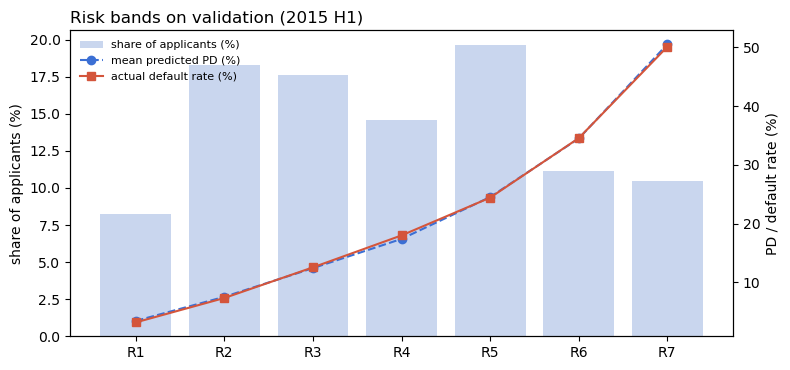

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(bands))
ax.bar(x, bands["share"] * 100, color="#c9d6ee", label="share of applicants (%)")
ax.set_ylabel("share of applicants (%)")
ax2 = ax.twinx()
ax2.plot(x, bands["mean_pd"] * 100, "o--", color="#3b6fd4", label="mean predicted PD (%)")
ax2.plot(x, bands["default_rate"] * 100, "s-", color="#d4553b", label="actual default rate (%)")
ax2.set_ylabel("PD / default rate (%)")
ax.set_xticks(x, bands.index)
ax.set_title("Risk bands on validation (2015 H1)", loc="left")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / "f3_risk_bands.png", dpi=150); plt.show()

## 6. Decision thresholds from the business targets
- **APPROVE** if PD ≤ the highest threshold at which the approved book's actual default rate is **≤ 12%**.
- **DECLINE** if PD ≥ the lowest threshold above which applicants' actual default rate is **≥ 40%**.
- **REVIEW** in between.

Searched on a 0.5-point grid using the out-of-fold PDs.

In [8]:
APPROVED_BOOK_MAX_DEFAULT, DECLINE_GROUP_MIN_DEFAULT, REVIEW_MAX_SHARE = 0.12, 0.40, 0.35
grid = np.round(np.arange(0.005, 0.995, 0.005), 3)
search = pd.DataFrame({"threshold": grid,
                       "approve_share": [(pd_oof <= t).mean() for t in grid],
                       "approved_default_rate": [y_val[pd_oof <= t].mean() if (pd_oof <= t).any() else np.nan for t in grid],
                       "decline_share": [(pd_oof >= t).mean() for t in grid],
                       "declined_default_rate": [y_val[pd_oof >= t].mean() if (pd_oof >= t).any() else np.nan for t in grid]})
t_approve = float(search.loc[search["approved_default_rate"] <= APPROVED_BOOK_MAX_DEFAULT, "threshold"].max())
t_decline = float(search.loc[(search["declined_default_rate"] >= DECLINE_GROUP_MIN_DEFAULT) & (search["threshold"] > t_approve), "threshold"].min())
policy["thresholds"] = {"approve_max_pd": t_approve, "decline_min_pd": t_decline}
print(f"APPROVE if PD <= {t_approve:.1%} | DECLINE if PD >= {t_decline:.1%} | REVIEW in between")
search[search["threshold"].isin([t_approve, t_decline])].round(4)

APPROVE if PD <= 22.5% | DECLINE if PD >= 27.5% | REVIEW in between


,threshold,approve_share,approved_default_rate,decline_share,declined_default_rate
44,0.225,0.6470,0.1190,0.3530,0.3584
54,0.275,0.7447,0.1357,0.2553,0.4014


In [9]:
val["decision"] = dl.decide(pd_cal, policy)
order = ["APPROVE", "REVIEW", "DECLINE"]
decisions = val.groupby("decision").agg(loans=("id", "size"), mean_pd=("pd", "mean"), default_rate=("target", "mean"),
                                        funded_m=("funded_amnt", lambda s: s.sum() / 1e6),
                                        expected_loss_m=("expected_loss", lambda s: s.sum() / 1e6),
                                        realised_loss_m=("realised_loss", lambda s: s.sum() / 1e6)).reindex(order)
decisions.insert(1, "share", decisions["loans"] / len(val))
decisions["loss_rate"] = decisions["realised_loss_m"] / decisions["funded_m"]
review_ok = decisions.loc["REVIEW", "share"] <= REVIEW_MAX_SHARE
print("Review queue <= 35% of applicants:", "PASS" if review_ok else "WARNING (staffing question)")
decisions.round(4)

Review queue <= 35% of applicants: PASS


,loans,share,mean_pd,default_rate,funded_m,expected_loss_m,realised_loss_m,loss_rate
decision,,,,,,,,
APPROVE,105309,0.6471,0.1184,0.1190,1451.5954,90.9731,90.7029,0.0625
REVIEW,15877,0.0976,0.2488,0.2462,234.8342,32.9553,34.2394,0.1458
DECLINE,41559,0.2554,0.4020,0.4013,704.7421,172.9021,190.3706,0.2701


In [10]:
print("Decision by risk band (share of applicants):")
pd.crosstab(val["band"], val["decision"], normalize="all").reindex(columns=order).mul(100).round(1)

Decision by risk band (share of applicants):


decision,APPROVE,REVIEW,DECLINE
band,,,
R1,8.3,0.0,0.0
R2,18.3,0.0,0.0
R3,17.6,0.0,0.0
R4,14.6,0.0,0.0
R5,6.0,9.8,3.9
R6,0.0,0.0,11.1
R7,0.0,0.0,10.5


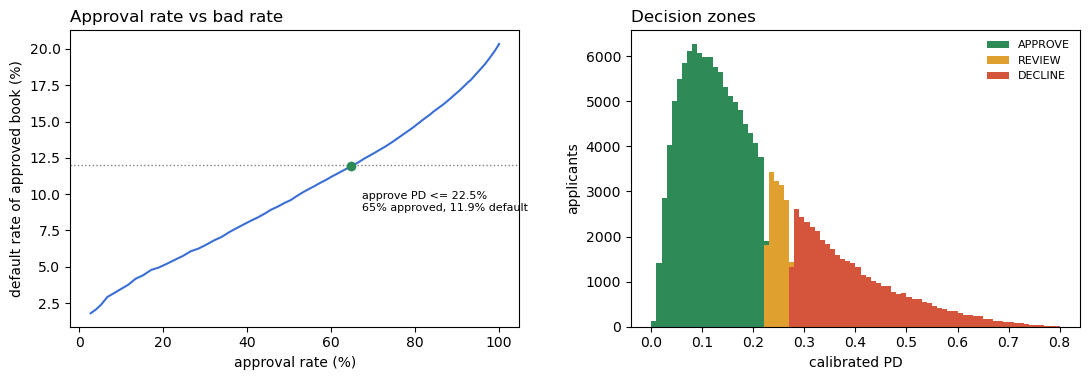

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
ax = axes[0]
ok = search["approve_share"] > 0.02
ax.plot(search.loc[ok, "approve_share"] * 100, search.loc[ok, "approved_default_rate"] * 100, color="#3b6fd4")
a = search.loc[search["threshold"] == t_approve].iloc[0]
ax.axhline(APPROVED_BOOK_MAX_DEFAULT * 100, color="grey", ls=":", lw=1)
ax.plot(a["approve_share"] * 100, a["approved_default_rate"] * 100, "o", color="#2e8b57")
ax.annotate(f"approve PD <= {t_approve:.1%}\n{a['approve_share']:.0%} approved, {a['approved_default_rate']:.1%} default",
            (a["approve_share"] * 100, a["approved_default_rate"] * 100), xytext=(8, -32), textcoords="offset points", fontsize=8)
ax.set_xlabel("approval rate (%)"); ax.set_ylabel("default rate of approved book (%)")
ax.set_title("Approval rate vs bad rate", loc="left")
ax = axes[1]
bins = np.linspace(0, 0.8, 81)
for name, color in [("APPROVE", "#2e8b57"), ("REVIEW", "#e0a030"), ("DECLINE", "#d4553b")]:
    ax.hist(pd_cal[val["decision"] == name], bins=bins, color=color, label=name)
ax.set_xlabel("calibrated PD"); ax.set_ylabel("applicants"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Decision zones", loc="left")
fig.tight_layout(); fig.savefig(RESULTS / "f3_thresholds.png", dpi=150); plt.show()

## 7. Expected-loss back-test
Predicted EL = PD × loan amount × EAD share × LGD, compared with the loss that really happened on validation loans (EAD − net recoveries for defaults). Recoveries on 2015 loans were still being collected when the data ends (2018 Q4), so realised loss may be slightly overstated.

In [12]:
def backtest(frame):
    return pd.Series({"loans": len(frame), "expected_loss_m": frame["expected_loss"].sum() / 1e6,
                      "realised_loss_m": frame["realised_loss"].sum() / 1e6,
                      "ratio": frame["expected_loss"].sum() / frame["realised_loss"].sum()})
el_backtest = pd.concat({"all": backtest(val),
                         **{f"term {t}": backtest(g) for t, g in val.groupby("term_months")},
                         **{d: backtest(val[val["decision"] == d]) for d in order}}, axis=1).T
el_ok = abs(el_backtest.loc["all", "ratio"] - 1) <= 0.10
print("Expected loss within +-10% of realised loss:", "PASS" if el_ok else "FAIL")
el_backtest.round(3)

Expected loss within +-10% of realised loss: PASS


,loans,expected_loss_m,realised_loss_m,ratio
all,162745.0,296.830,315.313,0.941
term 36,120790.0,117.552,117.895,0.997
term 60,41955.0,179.278,197.418,0.908
APPROVE,105309.0,90.973,90.703,1.003
REVIEW,15877.0,32.955,34.239,0.962
DECLINE,41559.0,172.902,190.371,0.908


## 8. Business impact (validation, vs approving everyone)
Two views, because REVIEW cases go to a person: *strict* (review = declined) and *lenient* (review = approved).

In [13]:
def book(mask, name):
    g = val[mask]
    return {"policy": name, "approved_loans": len(g), "approval_rate": len(g) / len(val), "default_rate": g["target"].mean(),
            "funded_m": g["funded_amnt"].sum() / 1e6, "realised_loss_m": g["realised_loss"].sum() / 1e6,
            "loss_rate": g["realised_loss"].sum() / g["funded_amnt"].sum()}
impact = pd.DataFrame([book(np.ones(len(val), bool), "approve everyone (what LendingClub funded)"),
                       book(val["decision"] == "APPROVE", "engine, strict (review = decline)"),
                       book(val["decision"] != "DECLINE", "engine, lenient (review = approve)")]).set_index("policy")
base = impact.iloc[0]
impact["defaults_avoided"] = (base["approved_loans"] * base["default_rate"] - impact["approved_loans"] * impact["default_rate"]).round()
impact["loss_avoided_m"] = base["realised_loss_m"] - impact["realised_loss_m"]
impact.round(4)

,approved_loans,approval_rate,default_rate,funded_m,realised_loss_m,loss_rate,defaults_avoided,loss_avoided_m
policy,,,,,,,,
approve everyone (what LendingClub funded),162745,1.0000,0.2035,2391.1717,315.3130,0.1319,0.0,0.0000
"engine, strict (review = decline)",105309,0.6471,0.1190,1451.5954,90.7029,0.0625,20587.0,224.6100
"engine, lenient (review = approve)",121186,0.7446,0.1357,1686.4296,124.9424,0.0741,16678.0,190.3706


## 9. What the engine returns for one applicant
Model PD → calibration → band, decision, expected loss → reason codes (Stage 2). This is the JSON shape the API in Stage 6 will return.

In [14]:
def score_one(i):
    row = X_val.iloc[[i]]
    p = float(dl.calibrate(booster.predict(row), calibrator)[0])
    out = dl.apply_policy([p], [val.loc[i, "loan_amnt"]], [val.loc[i, "term_months"]], policy)
    concepts = rc.concept_shap(booster.predict(row, pred_contrib=True), features)
    reasons = rc.explain(concepts.iloc[0], row.iloc[0])
    return {"probability_of_default": round(p, 4), "risk_band": str(out["risk_band"][0]), "decision": str(out["decision"][0]),
            "loan_amount": float(val.loc[i, "loan_amnt"]), "term_months": int(val.loc[i, "term_months"]),
            "expected_loss_usd": round(float(out["expected_loss"][0]), 2),
            "reasons": [r["reason"] for r in reasons["risk_factors"]],
            "strengths": [r["reason"] for r in reasons["protective_factors"]],
            "actual_outcome": "defaulted" if y_val[i] else "repaid"}

rng = np.random.default_rng(SEED)
example_idx = [int(rng.choice(np.flatnonzero(val["decision"].to_numpy() == d))) for d in order]
examples = [score_one(i) for i in example_idx]
for e in examples:
    print(json.dumps(e, indent=2))

{
  "probability_of_default": 0.2002,
  "risk_band": "R5",
  "decision": "APPROVE",
  "loan_amount": 14400.0,
  "term_months": 60,
  "expected_loss_usd": 1806.39,
  "reasons": [
    "Loan term: 60 months",
    "Credit score (FICO): 660",
    "Accounts opened in the last 24 months: 6",
    "Accounts opened in the last 12 months: 3"
  ],
  "strengths": [
    "State: OR",
    "Job title (historical default rate of similar titles): 11.7%"
  ],
  "actual_outcome": "repaid"
}
{
  "probability_of_default": 0.2251,
  "risk_band": "R5",
  "decision": "REVIEW",
  "loan_amount": 14525.0,
  "term_months": 60,
  "expected_loss_usd": 2049.13,
  "reasons": [
    "Loan term: 60 months",
    "Unused bankcard credit: $3",
    "Credit score (FICO): 680",
    "Revolving credit utilisation: 100.0%"
  ],
  "strengths": [
    "Installment accounts: 18",
    "Annual income: $79,000"
  ],
  "actual_outcome": "repaid"
}
{
  "probability_of_default": 0.383,
  "risk_band": "R6",
  "decision": "DECLINE",
  "loan_a

## 10. Checks and saving

In [15]:
checks = pd.DataFrame([
    {"check": "risk bands: default rate rises band to band", "required": True, "result": "PASS" if bands_monotone else "FAIL"},
    {"check": "expected loss within +-10% of realised loss", "required": True, "result": "PASS" if el_ok else "FAIL"},
    {"check": "review queue <= 35% of applicants", "required": False, "result": "PASS" if review_ok else "WARNING"},
    {"check": "approved book default rate <= 12% (out-of-fold PD)", "required": True,
     "result": "PASS" if search.loc[search["threshold"] == t_approve, "approved_default_rate"].iloc[0] <= APPROVED_BOOK_MAX_DEFAULT else "FAIL"},
])
all_required_pass = bool((checks.loc[checks["required"], "result"] == "PASS").all())
print(checks.to_string(index=False))
print("\nAll required checks pass:", all_required_pass)

                                             check  required result
       risk bands: default rate rises band to band      True   PASS
       expected loss within +-10% of realised loss      True   PASS
                 review queue <= 35% of applicants     False   PASS
approved book default rate <= 12% (out-of-fold PD)      True   PASS

All required checks pass: True


In [16]:
policy = {
    "version": "1.0", "stage": 3, "model": choice2["chosen_model"],
    "model_file": choice2["model_file"], "calibrator_file": choice2["calibrator_file"],
    "risk_bands": policy["risk_bands"],
    "thresholds": policy["thresholds"],
    "business_targets": {"approved_book_max_default_rate": APPROVED_BOOK_MAX_DEFAULT,
                         "decline_group_min_default_rate": DECLINE_GROUP_MIN_DEFAULT,
                         "threshold_grid_step": 0.005, "chosen_on": "validation (2015 H1), out-of-fold calibrated PD"},
    "loss_model": {**loss_model, "estimated_on": "defaulted training loans (2012-08..2014-12)",
                   "formula": "EL = PD x loan_amnt x ead_share[term] x lgd[term]",
                   "defaulted_loans": int(loss_model_table.loc["all", "defaulted_loans"])},
    "validation_summary": {d: {"share": float(decisions.loc[d, "share"]), "default_rate": float(decisions.loc[d, "default_rate"])} for d in order},
    "test_split": "sealed",
}
(RESULTS / "decision_policy.json").write_text(json.dumps(policy, indent=2), encoding="utf-8")
assert dl.load_policy() == policy, "decision.py does not read back the saved policy"
loss_model_table.to_csv(RESULTS / "f3_loss_model.csv")
bands.to_csv(RESULTS / "f3_risk_bands.csv")
decisions.to_csv(RESULTS / "f3_decisions.csv")
el_backtest.to_csv(RESULTS / "f3_el_backtest.csv")
impact.to_csv(RESULTS / "f3_business_impact.csv")
search.to_csv(RESULTS / "f3_threshold_search.csv", index=False)
checks.to_csv(RESULTS / "f3_checks.csv", index=False)
(RESULTS / "f3_examples.json").write_text(json.dumps(examples, indent=2), encoding="utf-8")
val[["id", "pd", "band", "decision", "expected_loss", "realised_loss", "target"]].to_parquet(RESULTS / "f3_validation_decisions.parquet", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['decision_policy.json', 'f3_business_impact.csv', 'f3_checks.csv', 'f3_decisions.csv', 'f3_el_backtest.csv', 'f3_examples.json', 'f3_loss_model.csv', 'f3_risk_bands.csv', 'f3_risk_bands.png', 'f3_threshold_search.csv', 'f3_thresholds.png', 'f3_validation_decisions.parquet', 'loss_table.parquet']


## 11. Conclusion

In [17]:
print(f"Loss model: EAD share {loss_model['ead_share']['36']:.2f} (36m) / {loss_model['ead_share']['60']:.2f} (60m), "
      f"LGD {loss_model['lgd']['36']:.2f} / {loss_model['lgd']['60']:.2f}")
print(f"Policy: APPROVE PD <= {t_approve:.1%} ({decisions.loc['APPROVE', 'share']:.0%} of applicants, "
      f"{decisions.loc['APPROVE', 'default_rate']:.1%} default) | REVIEW {decisions.loc['REVIEW', 'share']:.0%} | "
      f"DECLINE PD >= {t_decline:.1%} ({decisions.loc['DECLINE', 'share']:.0%}, {decisions.loc['DECLINE', 'default_rate']:.1%} default)")
print(f"Expected-loss back-test: predicted / realised = {el_backtest.loc['all', 'ratio']:.3f}")
print("All required checks pass:", all_required_pass, "| Next: Stage 4, the scoring package. Test split still sealed.")

Loss model: EAD share 0.57 (36m) / 0.71 (60m), LGD 0.89 / 0.89
Policy: APPROVE PD <= 22.5% (65% of applicants, 11.9% default) | REVIEW 10% | DECLINE PD >= 27.5% (26%, 40.1% default)
Expected-loss back-test: predicted / realised = 0.941
All required checks pass: True | Next: Stage 4, the scoring package. Test split still sealed.
